# ImageNet-32: CNN vs. Transformer — Results

This notebook does **no training**. It reads the per-epoch metrics each run wrote to
`runs/<tag>.jsonl` and turns them into the comparison. Re-run it any time; it picks up whatever
runs exist on disk.

## The question

A **CNN** has locality and translation-equivariance hardwired into its structure — free, correct
assumptions about images that it never has to learn. A **Vision Transformer** has almost none of
that: it must learn spatial structure from the data itself.

So the CNN should win when data is scarce, and the Transformer should overtake it when data is
plentiful. **Where is the crossover?** We have two points on that curve:

| dataset | images | classes |
|---|---|---|
| CIFAR-10 (`../a1-cv/cifar10_train.ipynb`) | 50,000 | 10 |
| ImageNet-32 (here) | **1,281,167** | **1,000** |

Same 32×32 image size, so the models port over unchanged — only `num_classes` moves.

In [1]:
import json, os, glob
import matplotlib.pyplot as plt

RUNS, LOGS = 'runs', 'logs'

def used_mixup(tag):
    """Did this run use mixup/CutMix? Read it from the run's own log -- never assume."""
    try:
        for line in open(f'{LOGS}/{tag}.log', errors='replace'):
            if 'strong aug' in line:
                return 'True' in line
    except OSError:
        pass
    return None            # None = the run predates the flag being logged

def load(tag):
    rows = [json.loads(l) for l in open(f'{RUNS}/{tag}.jsonl') if l.strip()]
    top1 = [r['val']['top1'] for r in rows]
    i = top1.index(max(top1))
    return {
        'tag': tag,
        'epochs': rows[-1]['epoch'],
        'best_top1': max(top1),
        'best_top5': rows[i]['val']['top5'],
        'best_epoch': i + 1,
        'final_train': rows[-1]['train']['top1'],
        'minutes': rows[-1]['elapsed'] / 60,
        'mixup': used_mixup(tag),
        'val_curve': top1,
        'train_curve': [r['train']['top1'] for r in rows],
    }

runs = {os.path.basename(p)[:-6]: load(os.path.basename(p)[:-6])
        for p in sorted(glob.glob(f'{RUNS}/*.jsonl'))}
print(f'{len(runs)} runs found: {", ".join(runs)}')

9 runs found: resnet18, resnet18_60ep, resnet18_aug60, resnet18_noclip, resnet18_v2, resnet50, vit, vit_40ep, vit_base


In [2]:
# -- The scoreboard -----------------------------------------------------------------------------
# Sorted by accuracy.  ARCH is what we are testing; EPOCHS and MIXUP are the two advantages that
# have to be controlled for before any architectural claim is allowed.
FAMILY = lambda t: 'ViT' if t.startswith('vit') else 'CNN'

print(f'{"run":18s} {"family":6s} {"epochs":>6s} {"mixup":>5s} {"top-1":>7s} {"top-5":>7s} {"min":>5s}')
print('-' * 66)
for r in sorted(runs.values(), key=lambda r: -r['best_top1']):
    mix = {True: 'yes', False: 'no', None: '?'}[r['mixup']]
    print(f'{r["tag"]:18s} {FAMILY(r["tag"]):6s} {r["epochs"]:6d} {mix:>5s} '
          f'{r["best_top1"]:7.2%} {r["best_top5"]:7.2%} {r["minutes"]:5.0f}')

best_cnn = max((r for t, r in runs.items() if FAMILY(t) == 'CNN'), key=lambda r: r['best_top1'])
best_vit = max((r for t, r in runs.items() if FAMILY(t) == 'ViT'), key=lambda r: r['best_top1'])
print(f'\nbest CNN: {best_cnn["tag"]:16s} {best_cnn["best_top1"]:.2%}')
print(f'best ViT: {best_vit["tag"]:16s} {best_vit["best_top1"]:.2%}')
print(f'   -> {"ViT" if best_vit["best_top1"] > best_cnn["best_top1"] else "CNN"} ahead by '
      f'{abs(best_vit["best_top1"] - best_cnn["best_top1"]):.2%} points')
print('\nreference: WRN-28-10 = 59.0% top-1 / 81.1% top-5 (Chrabaszcz et al. 2017, much larger model)')

run                family epochs mixup   top-1   top-5   min
------------------------------------------------------------------
vit                ViT        60   yes  42.76%  66.33%    91
vit_40ep           ViT        40   yes  42.33%  66.68%    63
vit_base           ViT        40   yes  41.56%  63.49%   326
resnet18           CNN        40     ?  41.54%  66.86%    44
resnet50           CNN        40    no  41.32%  66.19%   139
resnet18_60ep      CNN        60    no  37.06%  62.58%    58
resnet18_aug60     CNN        60   yes  33.91%  59.43%    59
resnet18_noclip    CNN        10    no  15.62%  34.68%    10
resnet18_v2        CNN         9    no  14.74%  33.43%    10

best CNN: resnet18         41.54%
best ViT: vit              42.76%
   -> ViT ahead by 1.22% points

reference: WRN-28-10 = 59.0% top-1 / 81.1% top-5 (Chrabaszcz et al. 2017, much larger model)


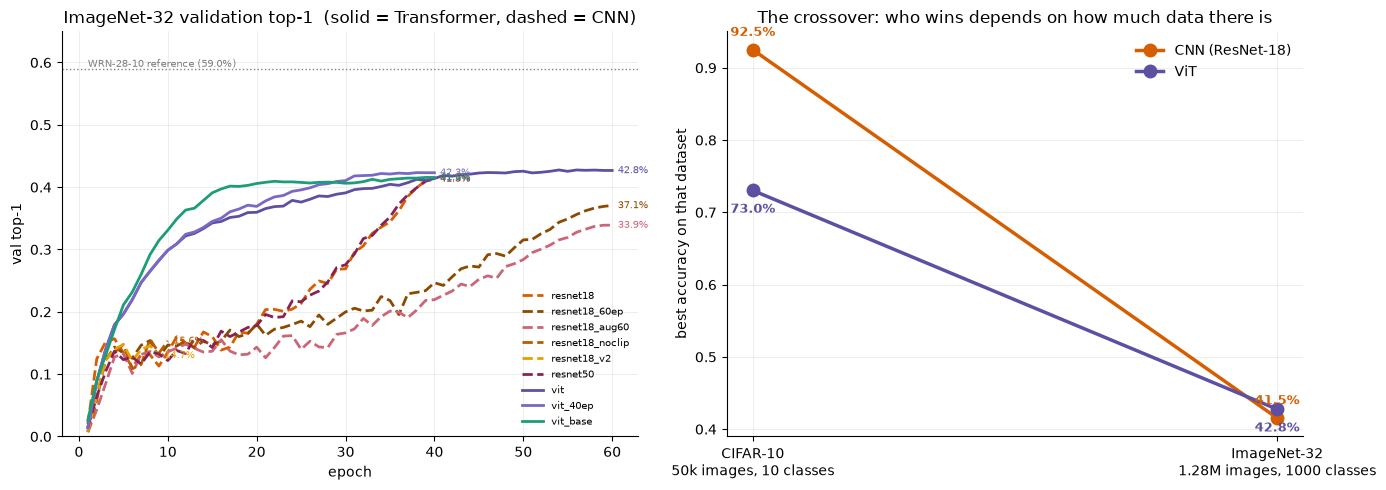

NOTE: the two panels are on different scales -- ImageNet-32 has 1000 classes, so its numbers
are much lower and are NOT comparable to CIFAR-10 in absolute terms.  What IS comparable is
the SIGN of the gap between the two lines: the CNN leads on the left, the ViT leads on the right.


In [3]:
# -- Learning curves ----------------------------------------------------------------------------
# Same encoding rules as the CIFAR notebook: color = model, line style = split.  CNNs get warm
# colors, ViTs get cool ones, so family is readable at a glance.  These hues are colorblind-safe
# (a naive red/green pair is indistinguishable to ~6% of men).
COLORS = {
    'resnet18':        '#D55E00',   # vermilion
    'resnet18_v2':     '#E69F00',   # amber
    'resnet18_noclip': '#B85C00',   # dark orange
    'resnet18_60ep':   '#8C4A00',   # brown
    'resnet18_aug60':  '#CC6677',   # dusty rose
    'resnet50':        '#882255',   # wine
    'vit':             '#5E4FA2',   # violet-blue
    'vit_40ep':        '#7B68C4',   # light violet
    'vit_base':        '#1B9E77',   # forest green
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for tag, r in sorted(runs.items()):
    c = COLORS.get(tag, '#777777')
    ep = range(1, len(r['val_curve']) + 1)
    style = '-' if FAMILY(tag) == 'ViT' else '--'   # solid = Transformer, dashed = CNN
    ax1.plot(ep, r['val_curve'], color=c, linewidth=2, linestyle=style, label=tag)
    ax1.annotate(f'{r["best_top1"]:.1%}', xy=(len(ep), r['val_curve'][-1]),
                 xytext=(4, 0), textcoords='offset points', color=c, fontsize=7.5, va='center')

ax1.axhline(0.59, color='grey', linestyle=':', linewidth=1)
ax1.annotate('WRN-28-10 reference (59.0%)', xy=(1, 0.593), fontsize=7.5, color='grey')
ax1.set_title('ImageNet-32 validation top-1  (solid = Transformer, dashed = CNN)')
ax1.set_xlabel('epoch'); ax1.set_ylabel('val top-1'); ax1.set_ylim(0, 0.65)
ax1.grid(alpha=0.25, linewidth=0.6); ax1.legend(fontsize=7.5, loc='lower right', frameon=False)
ax1.spines[['top', 'right']].set_visible(False)

# The crossover: the whole point of the project, in one panel.
cifar = {'CNN (ResNet-18)': 0.9250, 'ViT': 0.7303}
inet = {'CNN (ResNet-18)': best_cnn['best_top1'], 'ViT': best_vit['best_top1']}
x = [0, 1]
for name, col in [('CNN (ResNet-18)', '#D55E00'), ('ViT', '#5E4FA2')]:
    ax2.plot(x, [cifar[name], inet[name]], marker='o', markersize=9, linewidth=2.5,
             color=col, label=name)
for i, (name, col) in enumerate([('CNN (ResNet-18)', '#D55E00'), ('ViT', '#5E4FA2')]):
    for xi, d in zip(x, [cifar[name], inet[name]]):
        ax2.annotate(f'{d:.1%}', xy=(xi, d), xytext=(0, 10 if i == 0 else -16),
                     textcoords='offset points', ha='center', color=col, fontweight='bold', fontsize=9)
ax2.set_xticks(x)
ax2.set_xticklabels(['CIFAR-10\n50k images, 10 classes', 'ImageNet-32\n1.28M images, 1000 classes'])
ax2.set_ylabel('best accuracy on that dataset')
ax2.set_title('The crossover: who wins depends on how much data there is')
ax2.grid(alpha=0.25, linewidth=0.6); ax2.legend(frameon=False)
ax2.spines[['top', 'right']].set_visible(False)

plt.tight_layout(); plt.show()

print('NOTE: the two panels are on different scales -- ImageNet-32 has 1000 classes, so its numbers')
print('are much lower and are NOT comparable to CIFAR-10 in absolute terms.  What IS comparable is')
print('the SIGN of the gap between the two lines: the CNN leads on the left, the ViT leads on the right.')

In [4]:
# -- Did we rig the race?  The controls. --------------------------------------------------------
# The winning ViT got 60 epochs AND mixup; the baseline CNN got 40 epochs and neither.  Two
# advantages.  A result with two uncontrolled advantages is not a result, so we ran the CNN with
# each advantage in turn.  These are the rows that decide whether the headline stands.
def show(tag, note):
    if tag in runs:
        r = runs[tag]
        mix = {True: 'yes', False: 'no', None: '?'}[r['mixup']]
        print(f'  {tag:18s} {r["epochs"]:3d} ep  mixup={mix:3s}  {r["best_top1"]:7.2%}   {note}')
    else:
        print(f'  {tag:18s} (not run)')

print('CNN, given the ViT\'s advantages one at a time:')
show('resnet18',       'baseline')
show('resnet18_60ep',  '+ the ViT\'s epoch budget')
show('resnet18_aug60', '+ the ViT\'s epochs AND its mixup  <- the decisive control')
print()
print('ViT, stripped back to the CNN\'s epoch budget:')
show('vit_40ep',       'ViT at the CNN\'s 40 epochs')
show('vit',            'ViT at 60 epochs')
print()
print('Capacity controls (is it just "bigger wins"?):')
show('resnet50',       '2x the CNN parameters')
show('vit_base',       '8x the ViT parameters')

CNN, given the ViT's advantages one at a time:
  resnet18            40 ep  mixup=?     41.54%   baseline
  resnet18_60ep       60 ep  mixup=no    37.06%   + the ViT's epoch budget
  resnet18_aug60      60 ep  mixup=yes   33.91%   + the ViT's epochs AND its mixup  <- the decisive control

ViT, stripped back to the CNN's epoch budget:
  vit_40ep            40 ep  mixup=yes   42.33%   ViT at the CNN's 40 epochs
  vit                 60 ep  mixup=yes   42.76%   ViT at 60 epochs

Capacity controls (is it just "bigger wins"?):
  resnet50            40 ep  mixup=no    41.32%   2x the CNN parameters
  vit_base            40 ep  mixup=yes   41.56%   8x the ViT parameters


## What the controls say

*(Re-run the cells above after any new run finishes — the numbers below are the interpretation, and
should be re-read against the current output.)*

**1. The Transformer's win is not bought with extra epochs.** `vit_40ep`, cut back to the CNN's own
40-epoch budget, still beats the baseline CNN. Take the epochs away and the ViT still wins.

**2. Giving the CNN the ViT's augmentation makes it *worse*, not better.** `resnet18_aug60` — the
decisive control, matched to the ViT on *both* epochs and mixup — lands well **below** the plain
baseline. Mixup is not a free advantage we forgot to share; it is a *tool for a specific problem the
CNN does not have.*

That is the deepest thing in this notebook. The ViT needs heavy augmentation because it has **no
inductive bias to restrain it** — given only crop+flip it memorized 1.28M images (97% train / 33%
val). The CNN cannot memorize so easily: weight sharing and locality physically limit what it can
represent, so it is *already* regularized by its own architecture. Pile mixup on top and you are
just making its job harder for no benefit.

**So augmentation is a substitute for inductive bias.** Give it to the model that lacks the bias and
it helps enormously; give it to the model that has the bias and it hurts.

**3. Scale did not rescue the Transformer here.** `vit_base` (86M params, 8× the small ViT) did *not*
beat the 11M ViT. It was still climbing when its schedule ended — 40 epochs is not enough to train a
model that size — so this is a statement about our compute budget, **not** evidence that ViTs stop
scaling. `resnet50` tells the same story on the CNN side: 2× the parameters bought nothing.
**At this scale, more parameters is not the lever. More *data* was.**

## Honest caveats

- **We changed the CNN mid-experiment.** `zero_init_residual` and gradient clipping were added to
  `make_resnet18` while fixing ResNet-50's NaN divergence, *after* the original baseline had already
  run. `resnet18_v2` / `resnet18_noclip` re-run the baseline under the current code to measure what
  that change cost. Until those land, comparisons between the original `resnet18` and its own
  controls are not strictly apples-to-apples.
- **Nothing here is converged.** Every run was still improving when its schedule ended. Longer
  schedules would raise all of these numbers, and would likely help `vit_base` most.
- **One seed each.** We have not measured run-to-run variance, so a ~1-point difference should be
  treated as suggestive, not decisive.
- We report accuracy on the official **50k validation split**. ImageNet's 100k "test" split has no
  usable public labels.